# delexicalized syntax ICA space

This is a **development workbook** for the delex.py 
that produces the charts used in the book.

In [1]:
# Some useful libraries

import pandas as pd
import joblib
import numpy as np

import dask.dataframe as ddf

import sample_group_stats as sgstat
from sample_group import SG
import extools as ex

import databox as db
import syn_tree

OK -- read the ontology db (19571, 4)
Restored 303734 tags and 191240 tokens. Run update_corpus_tagdata() to update.
-- loaded the skipgram model tank/fasttext_8.model --


In [2]:
# These are the methods for updating the data sets.
# We will load the prepared data below (faster).

def refresh_token_arcs_tsv():
    '''
    This block computes all the token arcs in separate sample groups.
    Run only once after updating the data set.
    '''
    
    s_groups = SG._get_group_list()
    # s_groups = ['Life#life'] # for updating individual groups

    for sg_id in s_groups:

        print (sg_id)
        my_sg = SG(sg_id)
        b_td = my_sg.get_tokendict()
        zzzs = []
        rrtokendict = my_sg.get_rr_token_dict()

        for rr,c_df in rrtokendict.items():
            tokens = c_df.index.droplevel(0)
            zz=[b_td[tok_id]['t_arcs_ex_term'].assign(token=tok_id) for tok_id in tokens]
            zz_df = pd.concat(zz).reset_index(drop=True).assign(relrole=rr)        
            zzzs.append(zz_df)

        f_path = 'plots/'+my_sg.group_name+'/token_arcs.tsv'
        zzz_df = pd.concat(zzzs)
        zzz_df = pd.DataFrame(zzz_df,columns=list(zzz_df.columns[-2:])+list(zzz_df.columns[:-2]))    
        zzz_df.to_csv(f_path,sep='\t',index=False)
        print("Written %s" % f_path)
    

def refresh_feature_Df_n_per_cat_pq():
    '''
    Compute the Feature frequency distribution KL 
    element-wise divergence, per-category.
    '''
    
    feat_d_df = pd.read_csv('plots/feature_Df_n_per_cat.tsv',sep='\t')
    feat_d_df.drop(columns=['Unnamed: 0'],inplace=True)
    feat_d_df.set_index('feat',inplace=True)
    feat_d_df['arcpath']=feat_d_df.index.str.replace('\s.*','',regex=True)
    feat_d_df.to_parquet('plots/feature_Df_n_per_cat.pq')

    
    

In [3]:
# Read all the token arcs in separate sample groups.
#
# If not prepared yet, then run the previous block with compute_all = True


def fetch_token_arcs():
    token_arcs_df = ddf.read_csv('plots/*/token_arcs.tsv',sep='\t',assume_missing=True).compute()
    token_arcs_df.drop(columns=['token.1'],inplace=True)
    return token_arcs_df


token_arcs_df = fetch_token_arcs()
token_arcs_df.sample(5)

,token,relrole,arcpath,lemma,upos,widx
16208,Pro-b864_461_Velociraptor-2,taxongroup_topic,nsubj<obj>,leg,NOUN,6.0
7198,All-1529_9_bear-9,adaptation_topic,obl<,translate,VERB,6.0
1154,Tyr-70f1_177_predators-9,adaptation_comment,nmod<case>,along,ADP,3.0
19396,Man-5a67_68_mangrove-33,taxongroup_topic,nsubj<advcl>,float,VERB,13.0
12374,Igu-7a3f_58_lizards-10,taxongroup_comment,compound<list<appos>,lizard,NOUN,4.0


In [4]:
# Read the per-category Feature-frequency-distribution 
# with element-wise KL divergence
# as a "significance measure"

feat_d_df=pd.read_parquet('plots/feature_Df_n_per_cat.pq')
feat_d_df.groupby('relrole').sample(2)


,relrole,Df,n,arcpath
feat,,,,
conj<nmod> geography,adaptation_comment,0.0001,2,conj<nmod>
nsubj<obj>conj> wolf,adaptation_comment,0.0003,8,nsubj<obj>conj>
appos<nsubj>det> the,adaptation_topic,0.0001,13,appos<nsubj>det>
conj<nmod<amod> many,adaptation_topic,0.0001,9,conj<nmod<amod>
conj<obl>case> ...,free_topic,0.0001,205,conj<obl>case>
nsubj<mark> when,free_topic,0.0001,45,nsubj<mark>
amod<conj<amod> ...,location_comment,0.0005,14,amod<conj<amod>
compound<appos<nsubj> ...,location_comment,0.0002,7,compound<appos<nsubj>
appos<nsubj<det> a,location_topic,0.0002,20,appos<nsubj<det>


### experimenting a delexicalized syntax ICA space built with the non-lexicalized features

We will run some ICA analysis on the "de-lexicalized features". 

We will concentrate on samples with the "most specific arcpaths", which are dependent on the relation-role category in question. The get_rr_plain_arcpaths will define the set (top 30) of arc-paths to be included in the analysis.



In [5]:
# Now we compose a data set, that is filtered conveniently for our analysis.


In [6]:
def get_rr_plain_arcpaths(my_rel_role, n_lim=30):
    '''
    This selects the "most specific" arcpaths, 
    coined as "de-lexical features"
    by their computed element-wise KL divergence **Dx**
    '''

    ap_df = feat_d_df[feat_d_df.index.str.contains('...',regex=False)]
    aps = ap_df[ap_df.relrole==my_rel_role].sort_values('Df',ascending=False)

    # Limit to top 30 arcpaths with highest D

    delex_f = aps.head(n_lim).Df
    delex_f.index = aps.head(n_lim).arcpath
    return delex_f





In [7]:

# Sample of the likely most specific arcpaths, 
# using relation-role category: "adaptation_comment"

my_rel_role = 'adaptation_comment'
delex_D = get_rr_plain_arcpaths(my_rel_role)
delex_D.head(5) # with D


arcpath
amod<              0.0207
cop>               0.0122
nsubj>             0.0112
nsubj<obj>conj>    0.0108
amod<case>         0.0088
Name: Df, dtype: float64

In [8]:
#pd.DataFrame([{'obj':x,'class':str(eval(x+'.__class__'))} for x in dir() if not x.startswith('_')])\
#.sort_values('class')

In [9]:

def get_xtab_dfs(ap_list):
    '''
    cross-tabulation between arcpath-features and tokens.
    '''
    
    # cross-tab of all token-arcpaths (in ap_list)

    arcs = token_arcs_df[token_arcs_df.arcpath.isin(ap_list)]    
    ap_cross_ref_df = pd.crosstab(arcs.token,arcs.arcpath)

    # cross-tab of RR token-arcpaths (in ap_list)
    
    rr_tok_arc_df = token_arcs_df.groupby("relrole").get_group(my_rel_role)
    rr_tok_arc_df = rr_tok_arc_df[rr_tok_arc_df.arcpath.isin(ap_list)]
    
    ap_cross_df = pd.crosstab(rr_tok_arc_df.token,rr_tok_arc_df.arcpath)

    return ap_cross_df, ap_cross_ref_df

ap_cross_df, ap_cross_ref_df = get_xtab_dfs(delex_D.index)



In [10]:
# Create an ICA projection from the frequency table.

from sklearn.decomposition import FastICA

ica_tr = FastICA(n_components=5,max_iter=2048,random_state=42)
ica_tr.fit(ap_cross_df)


FastICA(max_iter=2048, n_components=5, random_state=42)

In [11]:
ap_cross_ref_df.sample(5).T.sample(5)


token,Acc-423f_2_birds-7,Ada-f37b_60_snakes-16,Aar-5e58_2_nocturnal-18,Mou-9e66_14_hare-17,Lon-b0af_261_owls-4
arcpath,,,,,
amod<obj<,0,0,0,0,0
nmod>conj>,0,0,0,0,0
amod<nmod>case>,0,0,1,0,0
nsubj>,0,0,0,0,0
nsubj<obj>conj>,0,0,0,0,0


In [12]:
ap_cross_df.sample(5).T.sample(5)


token,Lep-7440_55_Predators-1,Bov-d455_13_social-6,Ter-605f_11_metamorphosis-15,Gia-2984_15_semelparous-4,Koa-c4cf_136_herbivorous-3
arcpath,,,,,
amod<nmod<,0,1,0,0,0
nmod>amod>,0,0,0,0,0
amod>,0,0,1,0,0
amod<conj>,0,1,0,0,0
obl>case>,0,0,0,0,0


In [13]:
# Using the ICA model and Seaborn library, do a sample validation plot

plot_df = pd.DataFrame(ica_tr.transform(ap_cross_df)[:,:])
plot_df.rename(columns={plot_df.columns[-1]:'e'},inplace=True)


def seaborn_sample():

    import seaborn as sns


    sns.pairplot(plot_df,hue='e',palette='icefire_r',diag_kind="kde",corner=True,plot_kws={'alpha':0.5})

In [14]:
# Show features with the highest and lowest IC0 component value

comps_df = pd.DataFrame(ica_tr.components_.round(2),columns=ap_cross_df.columns).T
comps_df.sort_values(0,inplace=True)
pd.concat([comps_df.head(5),comps_df.tail(5)])

,0,1,2,3,4
arcpath,,,,,
nmod>conj>,-0.98,0.18,-0.00,-0.03,-0.00
obj<,-0.28,0.20,0.06,0.13,0.01
nmod>case>,-0.25,-0.64,0.01,-0.28,0.00
nmod>,-0.25,-0.63,0.01,-0.28,0.00
nmod>amod>,-0.00,-0.34,0.03,-0.14,0.01
nsubj>,0.26,-0.31,-0.59,0.23,-0.02
amod<case>,0.29,-0.18,0.17,-0.41,0.02
amod<,0.35,-0.15,0.22,-0.67,0.02
amod>,0.47,-0.31,0.96,0.51,0.04


In [15]:
# Below is the same with a graphical analysis

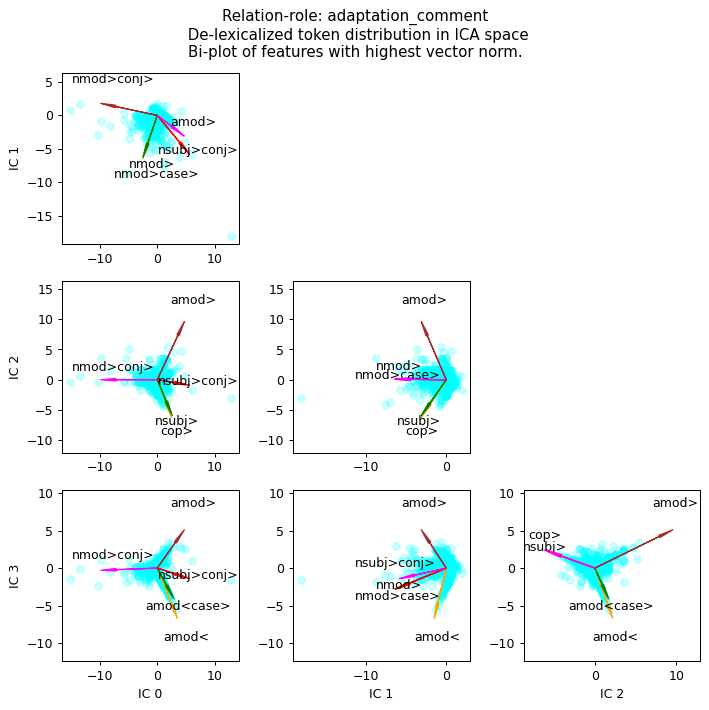

In [16]:
from matplotlib import figure, pyplot as plt
import matplotlib as mpl

def make_grid(ica_tr, plot_df, comps_df):

    fig = figure.Figure(figsize=(8,8),dpi=90)
    fig.set_tight_layout(20)

    DD = ica_tr.n_components-2 #  -1 for cross projection, -1 for error comp

    axs = fig.subplots(DD,DD,sharey=False,sharex=False)

    legends = []
    #ells = []
    markers = 'oPxXDH<>'
    colors = ['orange','green','red','magenta','brown','blue','maroon','pink','brown','purple']


    for Dy in range(1,DD+1):
        for Dx in range(0,Dy):          
            ax = axs[Dy-1,Dx]

            if Dx==0:
                ax.set_ylabel("IC %d" % Dy)

            if Dy==DD:
                ax.set_xlabel("IC %d" % Dx)

            xx=np.array(plot_df[[Dx,Dy]])
            ax.plot(xx[:,0],xx[:,1],'o',alpha=0.2,color='cyan')


            coli = 0
            arrows_n = 5
            arrow_df = (comps_df[[Dx,Dy]])*10
            arrow_df.columns=['x','y']
            show_arr_list = ((arrow_df**2).sum(axis=1).
                            sort_values(ascending=False).head(arrows_n).index)
            arrow_df = arrow_df.loc[show_arr_list].sort_values('y')

            for arr in list(arrow_df.index):
                (x,y) = arrow_df.loc[arr]
                ax.annotate('',(x,y),xytext=(0,0),arrowprops={'width':0.02,'headwidth':2,'color':colors[coli]})
                legends.append(arr)
                xoff = 0.5*len(arr)
                yoff = (coli-2)*1.5
                ax.text(x-xoff,y+yoff,arr,fontsize=10)
                ax.plot(1.25*x,1.25*y+yoff,'-',color=colors[coli])
                coli += 1        


        for Dx in range(Dy,DD):
            ax = axs[Dy-1,Dx]
            ax.set_axis_off()
    return fig,axs

fig,axs = make_grid(ica_tr, plot_df, comps_df)
fig.suptitle('Relation-role: '+my_rel_role+
             '\n De-lexicalized token distribution in ICA space\n'+
             'Bi-plot of features with highest vector norm.')
fig


In [17]:
# Compare how the weight values match with Df

maxcomps = np.sqrt((comps_df**2).sum(axis=1)).sort_values(ascending=False)#.head(10)
maxcomps.name = 'weight'

maxcomps_w_Df = pd.concat([maxcomps,delex_D.loc[maxcomps.index]],axis=1)
maxcomps_w_Df['Nf']=ap_cross_df.sum().loc[maxcomps_w_Df.index]
maxcomps_w_Df

,weight,Df,Nf
arcpath,,,
amod>,1.224867,0.0038,1336
nmod>conj>,0.996845,0.0040,230
nsubj>conj>,0.823468,0.0024,75
amod<,0.801686,0.0207,792
cop>,0.775242,0.0122,471
nsubj>,0.751731,0.0112,431
nmod>case>,0.742024,0.0080,613
nmod>,0.733417,0.0081,609
nsubj<obj>conj>,0.729794,0.0108,370


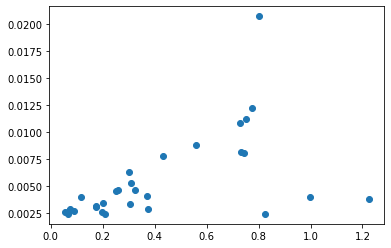

In [18]:
plt.plot(list(maxcomps_w_Df.weight),list(maxcomps_w_Df.Df),'o')

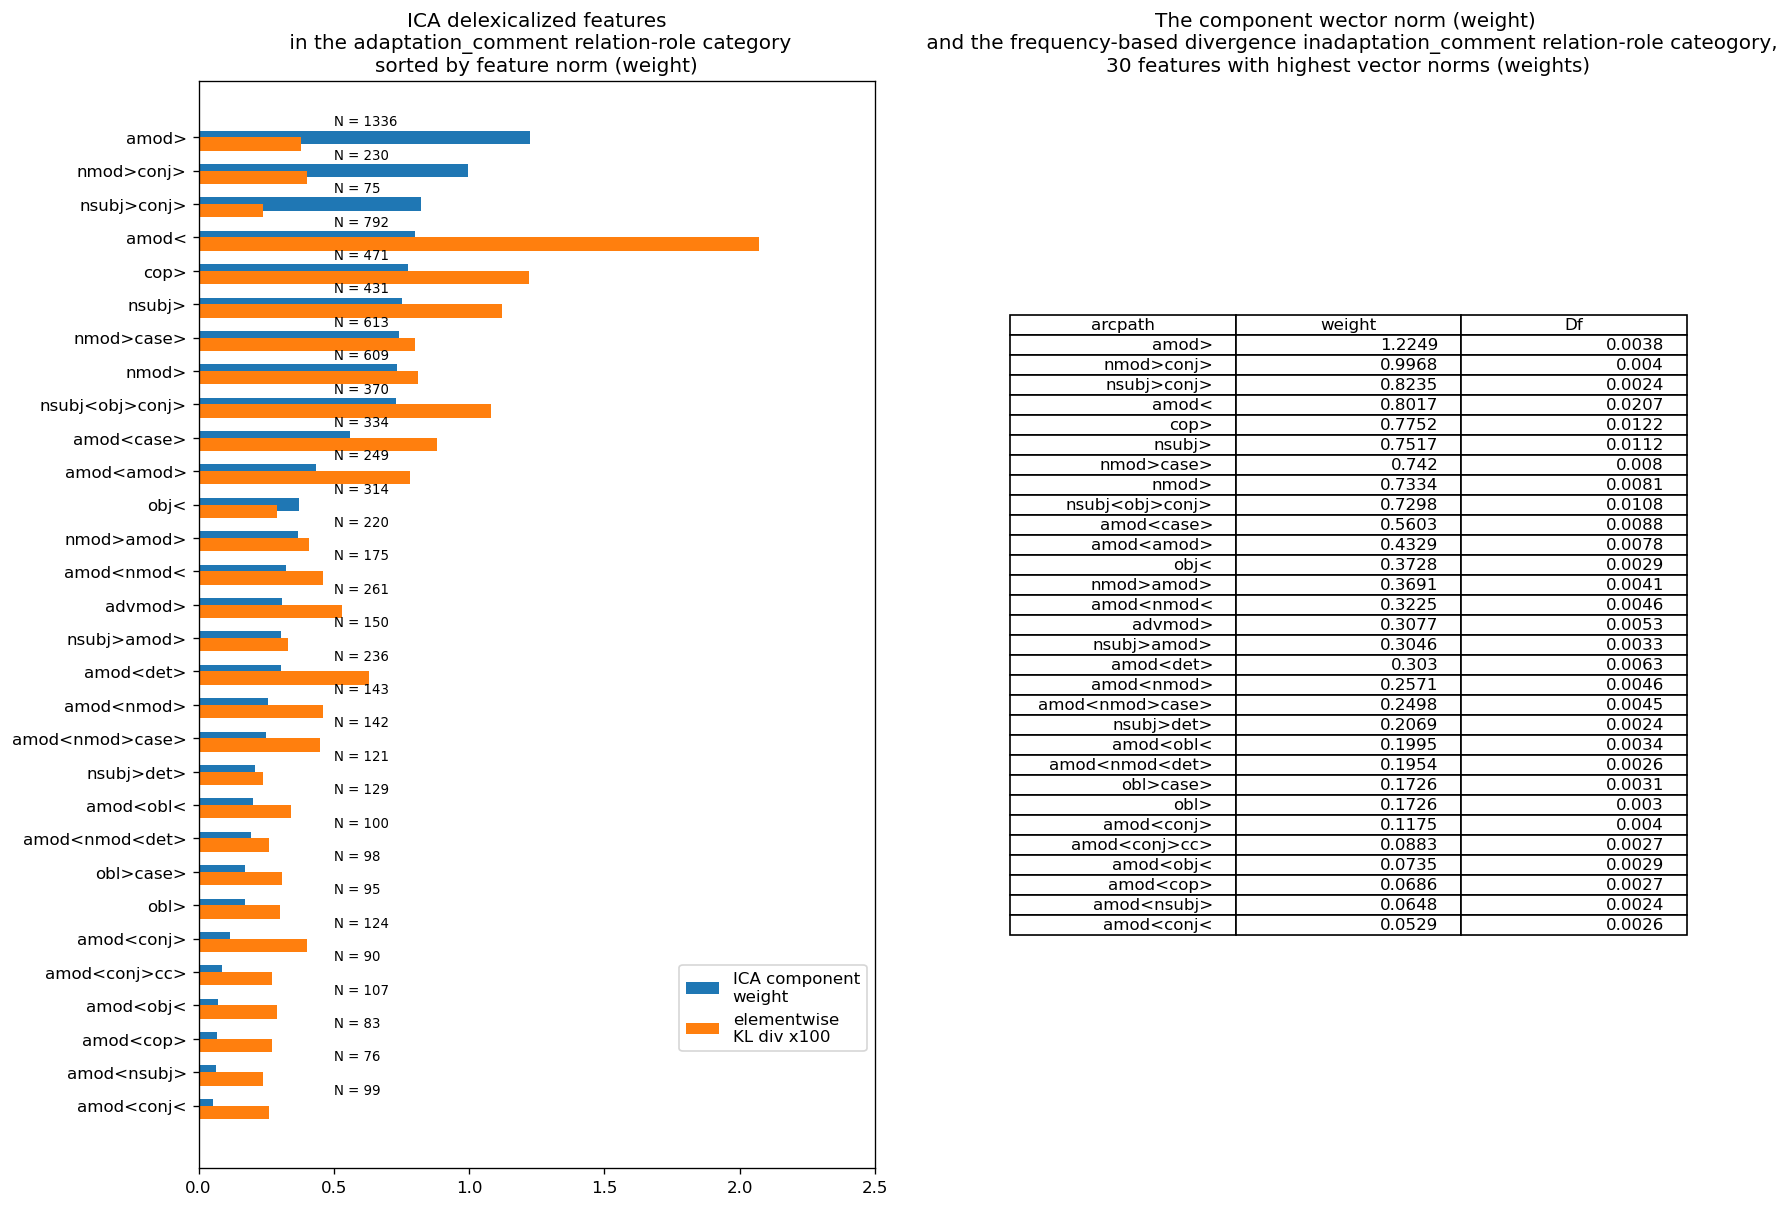

In [19]:

maxcomps_w_Df_r = maxcomps_w_Df.sort_values('weight',ascending=True)

fig_ = figure.Figure(figsize=(16,12),dpi=120)
fig_.tight_layout()

axs_ = fig_.subplots(1,2,sharey=False,sharex=False)
ax = axs_[0]

ax.barh(width=maxcomps_w_Df_r.weight,
         y=maxcomps_w_Df_r.index,
         height=.4)

ax.barh(width=maxcomps_w_Df_r.Df*100,
         y=pd.Series(range(len(maxcomps_w_Df_r.index)))-.2,
         height=.4)

for i in range(len(maxcomps_w_Df_r.index)):
    ax.text(0.5,0.35+i,'N = %d'%maxcomps_w_Df_r.Nf.iloc[i],
           fontsize=8)

ax.legend(['ICA component\nweight','elementwise\nKL div x100'],
         loc = 'lower right',
         bbox_to_anchor=(1,.1))

ax.set_xticks(np.arange(0,3,.5))
ax.set_title('ICA delexicalized features\n in the %s relation-role category\nsorted by feature norm (weight)'%my_rel_role)

# Also show with a table


stats_df = maxcomps_w_Df[['weight','Df']].reset_index().round(4)
stats_arr = np.array(stats_df)
ax = axs_[1]

table = ax.table(stats_arr,
         loc='center',
         colLabels=stats_df.columns,
         fontsize=22#,
         #rowLabels=stats_df.index#,
         #edges='vertical'
         )

ax.set_title('The component wector norm (weight) \n and the frequency-based divergence in'+
             my_rel_role+' relation-role cateogory,\n'+
             str(len(stats_df))+' features with highest vector norms (weights)')


ax.axes.set_axis_off()
fig_



In [20]:
# Then make normalized vectors for cosine similarity dendrogram

comps_w = np.sqrt((comps_df**2).sum(axis=1))
comps_w.name = 'weight'

comps_nrm = pd.DataFrame(np.divide(np.array(comps_df).T,np.array(comps_w)).T,index=comps_w.index)

dendro_comps = comps_nrm.loc[maxcomps_w_Df.index] # selected
dendro_comps

,0,1,2,3,4
arcpath,,,,,
amod>,0.383715,-0.253089,0.783758,0.416372,0.032657
nmod>conj>,-0.983102,0.180570,-0.000000,-0.030095,-0.000000
nsubj>conj>,0.680050,-0.704338,-0.109294,-0.170013,0.024288
amod<,0.436580,-0.187106,0.274422,-0.835739,0.024947
cop>,0.322480,-0.399875,-0.799750,0.309581,-0.025798
nsubj>,0.345868,-0.412381,-0.784855,0.305960,-0.026605
nmod>case>,-0.336916,-0.862505,0.013477,-0.377346,0.000000
nmod>,-0.340870,-0.858993,0.013635,-0.381775,0.000000
nsubj<obj>conj>,0.027405,0.095917,-0.109620,-0.068512,-0.986579


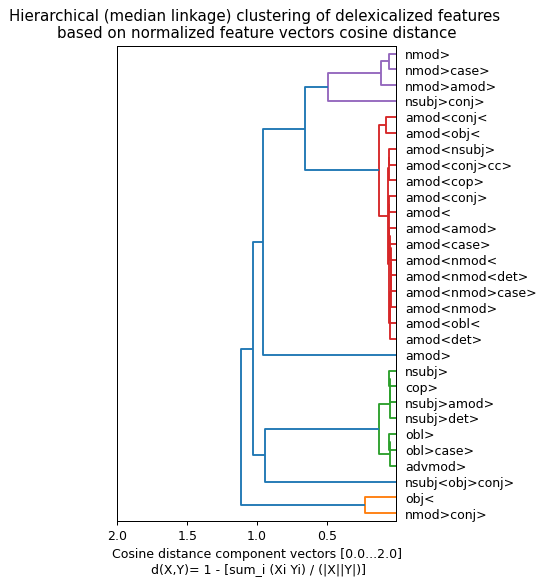

<Figure size 432x288 with 0 Axes>

In [21]:
from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist

import numpy as np
from scipy.cluster import hierarchy

from matplotlib import figure, pyplot as plt

dists2= pdist(np.array(dendro_comps),metric='cosine')
Z = hierarchy.linkage(dists2, 'ward')

fig = figure.Figure(figsize=(4,7),dpi=90)
axs = fig.subplots(1,1,sharey=False)
ax = axs

Z = hierarchy.linkage(dists2+.05, 'median')
#Z = hierarchy.linkage(dists2+.05, 'complete')
#Z = hierarchy.linkage(dists2, 'single')

plt.figure()
dn = hierarchy.dendrogram(Z,ax=ax,
                          orientation='left',
                          labels=dendro_comps.index,
                          color_threshold=.5)
ax.axes.set_xticks(np.arange(2.0,0,-.5))
ax.axes.set_title('Hierarchical (median linkage) clustering of delexicalized features \n'+
                 'based on normalized feature vectors cosine distance')
ax.axes.set_xlabel('Cosine distance component vectors [0.0...2.0]\n d(X,Y)= 1 - [sum_i (Xi Yi) / (|X||Y|)]')

fig

$d(x,y)=1-\sum_i(x_i \cdot y_i)~/~(|x|~|y|)$

In [22]:
my_leaves = pd.DataFrame(dn['leaves_color_list'],dn['ivl'],columns=['leaf_group'])

In [35]:
token_arcs_df[~token_arcs_df.duplicated(['token','relrole'],keep='first')].relrole.value_counts()

relrole
free_topic            21326
taxongroup_topic      10274
taxongroup_comment    10134
adaptation_topic       4966
location_topic         3961
adaptation_comment     3282
location_comment       2223
Name: count, dtype: int64[pyarrow]

In [23]:

a_df = (ap_cross_df>0)*1
b_df = (ap_cross_ref_df>0)*1

n2 = len(token_arcs_df.token.unique())
n1 = len(token_arcs_df[token_arcs_df.relrole == my_rel_role].token.unique())

print("sample group sizes (n1, n2): %d , %d"%(n1,n2))



ap_a = 'obj<'
ap_b = 'nmod>conj>'

def ap_combo_poisson_test(ap_a = 'obj<', ap_b = 'nmod>conj>'):
    k1,k2 = np.sum(a_df[ap_a] * a_df[ap_b]), np.sum(b_df[ap_a] * b_df[ap_b])
    print("events of                  : %s, %s" % (ap_a, ap_b))
    print("event frequencies: (k1, k2): %d , %d"%(k1,k2))

    import scipy.stats as sst 
    p_stat,p_pval=sst.poisson_means_test(k1,n1,k2,n2)
    print("p_stat %1.5f, p_pval %1.5f "%(p_stat,p_pval))
    return p_stat,p_pval,k1,k2

ap_combo_poisson_test(ap_a,ap_b)
    

sample group sizes (n1, n2): 3282 , 49606
events of                  : obj<, nmod>conj>
event frequencies: (k1, k2): 29 , 134
p_stat 3.70161, p_pval 0.00619 


(3.7016128140175755, 0.006193508275691265, 29, 134)

In [24]:
ap_pairs = []

for lg,leaves in my_leaves.groupby(my_leaves.leaf_group):
    my_aps = list(leaves.index.unique())
    for i,ap_a in enumerate(my_aps):
        for ap_b in my_aps[:i]:
            if not (ap_a.startswith(ap_b) or ap_b.startswith(ap_a)):
                ap_pairs.append((ap_a,ap_b,lg))

    

In [25]:
x=[]
for ap_pair in ap_pairs:
    x.append(ap_combo_poisson_test(ap_pair[0],ap_pair[1]))
x_df = pd.DataFrame(x,columns=['stat','p_val','k1','k2'],index=ap_pairs)


events of                  : amod>, nsubj<obj>conj>
event frequencies: (k1, k2): 36 , 115
p_stat 4.69917, p_pval 0.00226 
events of                  : obj<, nmod>conj>
event frequencies: (k1, k2): 29 , 134
p_stat 3.70161, p_pval 0.00619 
events of                  : obl>case>, advmod>
event frequencies: (k1, k2): 30 , 47
p_stat 4.89275, p_pval 0.00842 
events of                  : obl>, advmod>
event frequencies: (k1, k2): 30 , 47
p_stat 4.89275, p_pval 0.00842 
events of                  : nsubj>det>, advmod>
event frequencies: (k1, k2): 31 , 93
p_stat 4.43364, p_pval 0.00419 
events of                  : nsubj>det>, obl>case>
event frequencies: (k1, k2): 23 , 49
p_stat 4.10077, p_pval 0.01183 
events of                  : nsubj>det>, obl>
event frequencies: (k1, k2): 23 , 49
p_stat 4.10077, p_pval 0.01183 
events of                  : nsubj>amod>, advmod>
event frequencies: (k1, k2): 38 , 85
p_stat 5.22660, p_pval 0.00283 
events of                  : nsubj>amod>, obl>case>
event fre

In [26]:
x_df.p_val = x_df.p_val.round(5)
x_df.sort_values('stat').tail(15)

,stat,p_val,k1,k2
"(nsubj>, obl>case>, C2)",7.123934,0.00006,68,136
"(nsubj>, obl>, C2)",7.123934,0.00006,68,136
"(amod<amod>, amod<det>, C3)",7.182522,0.00021,64,96
"(nmod>case>, nmod>amod>, C4)",7.347103,0.00000,157,963
"(cop>, obl>case>, C2)",7.423707,0.00003,74,149
"(cop>, obl>, C2)",7.423707,0.00003,74,149
"(amod<nsubj>, amod<cop>, C3)",7.560113,0.00010,68,83
"(cop>, nsubj>amod>, C2)",7.801545,0.00000,118,491
"(amod<case>, amod<nmod<det>, C3)",8.053593,0.00001,88,183
"(amod<amod>, amod<case>, C3)",8.335425,0.00001,88,144


In [27]:
# TODO nice examples

In [28]:

ap_a,ap_b = 'nsubj>', 'cop>'

In [29]:
examples_x=a_df[a_df[ap_a]*a_df[ap_b]>0]
examples_x.index[0:5]

Index(['Aar-5e58_110_nocturnal-4', 'Aes-417b_13_predators-5',
       'Aes-55d6_43_poisonous-14', 'Afr-354e_31_predator-7',
       'Afr-3b7b_174_predators-12'],
      dtype='string', name='token')

In [30]:
tok = ex.pretty_token('Aar-5e58_110_nocturnal-4')
tok.word_id,tok.t_synt

(4,
              form                 arcpath
 widx                                     
 1             The              nsubj>det>
 2        aardvark                  nsubj>
 3              is                    cop>
 4       nocturnal                        
 5             and                conj>cc>
 6              is               conj>cop>
 7               a               conj>det>
 8        solitary              conj>amod>
 9        creature                   conj>
 10           that   conj>acl:relcl>nsubj>
 11          feeds         conj>acl:relcl>
 12         almost                        
 13    exclusively  conj>acl:relcl>advmod>
 14             on                        )

In [31]:
#ex.pretty_token('Aca-0b77_3_plant-8')
#ex.pretty_token('Afr55ed_14_penguin-8')
#ex.pretty_token('Aar-5e58_102_dogs-18') # This is an excellent example (compound token)
ex.pretty_token('Afr-7494_249_social-2')

{'word_id': 2,
 't_arcs':                arcpath      lemma  upos  widx
 0            amod<det>        the   DET     1
 1                amod<   behavior  NOUN     3
 2      amod<nmod>nmod>   elephant  NOUN     5
 3      amod<nmod>case>         in   ADP     6
 4  amod<nmod>compound>  captivity  NOUN     7
 5           amod<nmod>     mimics  NOUN     8
 6      amod<nmod>nmod>      those  PRON    11,
 't_synt':            form              arcpath
 widx                                
 1           The            amod<det>
 2        social                     
 3      behavior                amod<
 4            of                     
 5     elephants      amod<nmod>nmod>
 6            in      amod<nmod>case>
 7     captivity  amod<nmod>compound>
 8        mimics           amod<nmod>
 9          that                     
 10           of                     
 11        those      amod<nmod>nmod>
 12           in                     ,
 'ctx': ['The',
  '[social]',
  'behavior of elephants 